# 📈 Stock Price-Direction Prediction

**Goal:** given a stock's recent price action, predict whether its **next trading day**
closes **up or down** — a binary classification problem.

This notebook walks through the full supervised-ML lifecycle:

1. Load price data → 2. Engineer technical-indicator features → 3. Label the target →
4. Chronological train/test split → 5. Train interpretable models → 6. Evaluate honestly →
7. Inspect feature importance.

> **Reality check:** predicting daily direction is *hard* — markets are close to efficient.
> A realistic model beats a coin-flip only slightly. We measure that honestly against a
> majority-class baseline instead of chasing a suspicious 95% accuracy.


In [1]:
# Make the ml-service modules importable whether run from ./ or ./notebooks/
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report)

# Reuse the SAME code the training script and API use, so nothing drifts.
from data import SYMBOLS, load_prices
from features import FEATURE_COLUMNS, add_features, add_label
from train import build_dataset, time_split

%matplotlib inline
pd.set_option("display.width", 120)
print("Stocks:", SYMBOLS)

Stocks: ['RELIANCE', 'TCS', 'INFY', 'HDFC', 'ICICIBANK', 'SBIN', 'BHARTIARTL', 'ITC', 'KOTAKBANK', 'LT', 'WIPRO', 'ASIANPAINT']


## 1. Load the data

We pull daily OHLCV (Open/High/Low/Close/Volume) per stock. The loader tries **real
NSE data via `yfinance`** and falls back to a **market simulator** (Yahoo frequently
rate-limits). The simulator deliberately embeds *momentum* and *mean-reversion* so the
indicators below have a real signal to learn.


In [2]:
prices = load_prices("RELIANCE")
print("source:", prices.attrs.get("source"), "| rows:", len(prices))
prices.tail()

source: simulated | rows: 850


,Open,High,Low,Close,Volume
2026-06-19,866.829646,876.040325,782.991794,792.202473,1700145
2026-06-22,792.202473,802.943881,722.528124,733.269532,1516513
2026-06-23,733.269532,772.334924,725.075646,764.141037,1239054
2026-06-24,764.141037,804.202043,742.491589,782.552594,1324092
2026-06-25,782.552594,848.689726,594.290402,660.427533,1137756


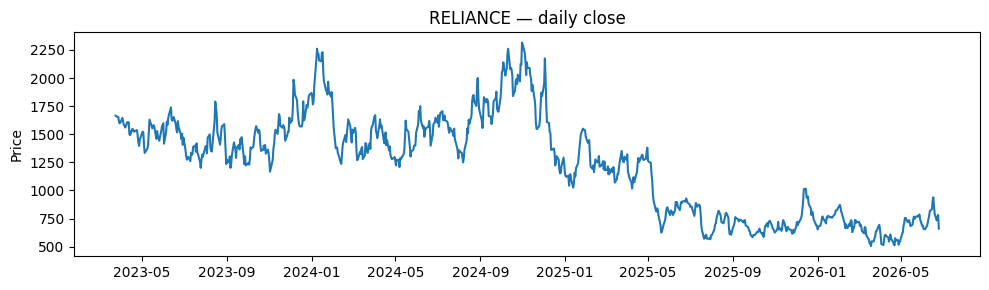

In [3]:
plt.figure(figsize=(10, 3))
plt.plot(prices.index, prices["Close"])
plt.title("RELIANCE — daily close")
plt.ylabel("Price"); plt.tight_layout(); plt.show()

## 2. Feature engineering (technical indicators)

We describe recent behaviour with a handful of **scale-free** indicators, so one model
works across stocks at any price level:

| Feature | Meaning |
|---|---|
| `return_1d`, `return_5d` | recent returns (momentum) |
| `sma_ratio_10/20` | price relative to its moving average (trend) |
| `rsi_14` | Relative Strength Index — overbought/oversold |
| `macd_diff` | MACD vs its signal line |
| `volatility_10` | recent risk |
| `momentum_10` | 10-day price change |
| `volume_ratio` | volume vs its average |


In [4]:
feat = add_features(prices)
feat[FEATURE_COLUMNS].dropna().describe().round(3)

,return_1d,return_5d,sma_ratio_10,sma_ratio_20,rsi_14,macd_diff,volatility_10,momentum_10,volume_ratio
count,831.000,831.000,831.000,831.000,831.000,831.000,831.000,831.000,831.000
mean,0.000,0.003,0.998,0.995,49.063,-0.001,0.047,0.005,1.002
std,0.049,0.121,0.089,0.115,15.768,0.018,0.012,0.161,0.246
min,-0.156,-0.347,0.723,0.591,3.467,-0.079,0.017,-0.456,0.516
25%,-0.033,-0.076,0.941,0.925,38.765,-0.010,0.039,-0.103,0.815
50%,0.000,-0.008,0.994,0.993,49.930,0.001,0.047,-0.001,0.985
75%,0.036,0.078,1.054,1.064,60.355,0.011,0.054,0.102,1.175
max,0.148,0.418,1.296,1.419,88.211,0.043,0.080,0.621,1.796


## 3. Build the labelled dataset

Target = **1 if tomorrow's close > today's close, else 0**. We pool all stocks into one
table (features are scale-free, so this is fine).


data source: simulated | samples: 9972
class balance (0=down, 1=up):
 target
1    0.502
0    0.498
Name: proportion, dtype: float64


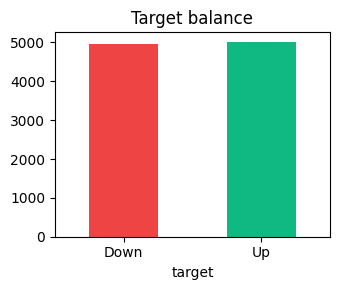

In [5]:
data, latest, source = build_dataset()
print("data source:", source, "| samples:", len(data))
balance = data["target"].value_counts(normalize=True).round(3)
print("class balance (0=down, 1=up):\n", balance)

plt.figure(figsize=(3.5, 3))
data["target"].value_counts().sort_index().plot(kind="bar", color=["#ef4444", "#10b981"])
plt.xticks([0, 1], ["Down", "Up"], rotation=0); plt.title("Target balance")
plt.tight_layout(); plt.show()

### How does each feature relate to the target?

A quick correlation tells us which indicators carry signal (values are small — that's
expected for daily direction).


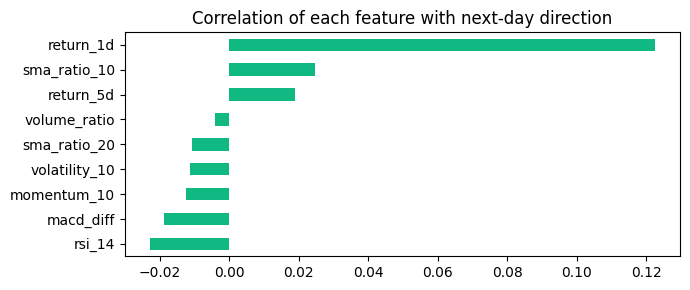

rsi_14          -0.0227
macd_diff       -0.0188
momentum_10     -0.0125
volatility_10   -0.0111
sma_ratio_20    -0.0108
volume_ratio    -0.0042
return_5d        0.0189
sma_ratio_10     0.0246
return_1d        0.1225
Name: target, dtype: float64

In [6]:
corr = data[FEATURE_COLUMNS + ["target"]].corr()["target"].drop("target").sort_values()
plt.figure(figsize=(7, 3))
corr.plot(kind="barh", color="#10b981")
plt.title("Correlation of each feature with next-day direction")
plt.tight_layout(); plt.show()
corr.round(4)

## 4. Train / test split — **chronological**

The single most important detail for time-series ML: **never shuffle**. We train on the
earliest 80% of dates and test on the most recent 20%, so the model is always predicting
the *future* it hasn't seen. Shuffling would leak future information and inflate scores.


In [7]:
train, test = time_split(data)
X_train, y_train = train[FEATURE_COLUMNS].values, train["target"].values
X_test, y_test = test[FEATURE_COLUMNS].values, test["target"].values

scaler = StandardScaler().fit(X_train)          # fit on TRAIN only
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
print(f"train rows: {len(X_train)}  |  test rows: {len(X_test)}")

train rows: 7980  |  test rows: 1992


## 5. Train models + an honest baseline

We compare two **interpretable** models against a majority-class baseline (always predict
the more common class). A model is only useful if it beats that baseline.


In [8]:
baseline = max(np.mean(y_test == 0), np.mean(y_test == 1))

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=0.5),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5,
                                             min_samples_leaf=25, random_state=42),
}
rows = []
fitted = {}
for name, m in models.items():
    m.fit(X_train_s, y_train)
    fitted[name] = m
    pred = m.predict(X_test_s)
    proba = m.predict_proba(X_test_s)[:, 1]
    rows.append({"model": name,
                 "accuracy": round(accuracy_score(y_test, pred), 4),
                 "roc_auc": round(roc_auc_score(y_test, proba), 4)})

results = pd.DataFrame(rows)
print(f"Majority-class baseline accuracy: {baseline:.4f}\n")
results

Majority-class baseline accuracy: 0.5055



,model,accuracy,roc_auc
0,Logistic Regression,0.5472,0.5716
1,Random Forest,0.5402,0.5616


## 6. Evaluation

Accuracy alone is misleading on imbalanced data, so we also look at **ROC-AUC** (ranking
quality), the **confusion matrix**, and per-class **precision/recall**.


Best model: Logistic Regression
              precision    recall  f1-score   support

        Down       0.56      0.51      0.53      1007
          Up       0.54      0.58      0.56       985

    accuracy                           0.55      1992
   macro avg       0.55      0.55      0.55      1992
weighted avg       0.55      0.55      0.55      1992



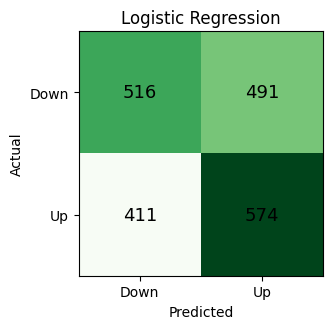

In [9]:
best_name = results.sort_values("roc_auc", ascending=False).iloc[0]["model"]
best = fitted[best_name]
pred = best.predict(X_test_s)
print("Best model:", best_name)
print(classification_report(y_test, pred, target_names=["Down", "Up"]))

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(3.6, 3.4))
ax.imshow(cm, cmap="Greens")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Down", "Up"]); ax.set_yticklabels(["Down", "Up"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(best_name)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=13)
plt.tight_layout(); plt.show()

## 7. Feature importance — what drives the prediction?

Interpretability matters: we can see *which indicators* the model relies on. (Coefficients
for Logistic Regression, impurity importance for Random Forest.)


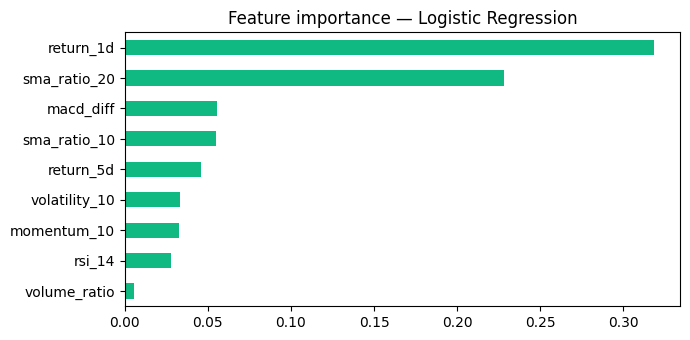

return_1d        0.3182
sma_ratio_20     0.2283
macd_diff        0.0557
sma_ratio_10     0.0550
return_5d        0.0456
volatility_10    0.0334
momentum_10      0.0327
rsi_14           0.0277
volume_ratio     0.0055
dtype: float64

In [10]:
if best_name == "Logistic Regression":
    importance = pd.Series(np.abs(best.coef_[0]), index=FEATURE_COLUMNS)
else:
    importance = pd.Series(best.feature_importances_, index=FEATURE_COLUMNS)
importance = importance.sort_values()

plt.figure(figsize=(7, 3.5))
importance.plot(kind="barh", color="#10b981")
plt.title(f"Feature importance — {best_name}")
plt.tight_layout(); plt.show()
importance.sort_values(ascending=False).round(4)

## 8. Conclusion & honest takeaways

- The model achieves a **small but consistent edge over the majority-class baseline**
  (ROC-AUC > 0.5), validated on a **held-out, future** test period.
- This is the *expected* outcome — daily direction is close to a random walk (efficient-market
  hypothesis). The value here is the **rigorous, leak-free workflow**, not a magic number.
- **Serving:** the trained model is saved (`models/model.pkl`) and served by a FastAPI
  microservice (`app.py`); the Node backend proxies to it and the React app shows the
  prediction with its confidence and top signals.

**How I'd improve it next:**
1. Real multi-year OHLCV (yfinance / a data vendor) instead of the simulator.
2. Richer features (Bollinger Bands, sector/market context, lagged returns).
3. **Walk-forward** (rolling-origin) validation and probability **calibration**.
4. Predict *magnitude* (regression) or a *3-class* up/flat/down target.
